# 07 - Player Trajectories

## Obiettivo

Questo notebook utilizza le coordinate dei giocatori sul campo prodotte dal notebook `06_player_localization.ipynb` per ricostruire le traiettorie temporali associate ai diversi `track_id`.

A partire dai dati:

(frame, time, track_id, court_x, court_y)

verranno calcolate informazioni dinamiche quali:

- traiettoria del giocatore;
- distanza percorsa;
- velocità istantanea;
- velocità media;
- accelerazione;
- direzione del movimento.

Verranno inoltre confrontate le coordinate originali con una versione temporalmente smussata, utile per ridurre le oscillazioni dovute agli errori di detection, tracking e omografia.

L'output principale sarà un dataset tabellare contenente, per ogni giocatore e per ogni istante temporale, posizione e feature cinematiche derivate.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Configurazione

In [4]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/basketball-thesis"
)

SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

LOCALIZATION_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "player_localization"
    / SEQUENCE_NAME
)

INPUT_CSV = (
    LOCALIZATION_DIR
    / f"{SEQUENCE_NAME}_localized_players.csv"
)

OUTPUT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "player_trajectories"
    / SEQUENCE_NAME
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Input:", INPUT_CSV)
print("Esiste:", INPUT_CSV.exists())
print("Output:", OUTPUT_DIR)

Input: /content/drive/MyDrive/basketball-thesis/experiments/player_localization/v_00HRwkvvjtQ_c001/v_00HRwkvvjtQ_c001_localized_players.csv
Esiste: True
Output: /content/drive/MyDrive/basketball-thesis/experiments/player_trajectories/v_00HRwkvvjtQ_c001


Caricamneto Localizzazioni

In [5]:
df = pd.read_csv(INPUT_CSV)

print("Numero osservazioni:", len(df))
print("Numero track ID:", df["track_id"].nunique())

df.head()

Numero osservazioni: 10911
Numero track ID: 27


,frame,time,track_id,confidence,pixel_x,pixel_y,court_x,court_y,inside_court
0,2,0.04,0,0.946324,497.440216,436.969055,15.356175,9.159191,True
1,2,0.04,1,0.918906,1012.134491,604.696655,20.980978,14.110223,True
2,2,0.04,2,0.847886,702.810364,625.620422,17.481428,14.445071,True
3,2,0.04,3,0.852696,1022.096680,497.540070,21.613432,11.348380,True
4,2,0.04,4,0.760169,705.832672,433.214172,18.022991,9.221877,True


Controllo delle colonne

In [6]:
required_columns = [
    "frame",
    "time",
    "track_id",
    "court_x",
    "court_y",
    "inside_court",
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

print("Colonne mancanti:", missing_columns)

assert len(missing_columns) == 0, (
    f"Mancano le colonne: {missing_columns}"
)

Colonne mancanti: []


## Pulizia preliminare

Per la ricostruzione delle traiettorie vengono considerate inizialmente solo le osservazioni proiettate all'interno dei limiti del campo.

Le coordinate esterne al campo possono derivare da:

- errori della bounding box;
- errori di tracking;
- imprecisioni dell'omografia;
- movimento della telecamera;
- giocatori temporaneamente fuori dall'area di gioco visibile.

Tali osservazioni non vengono eliminate dal dataset originale, ma escluse dalla prima analisi delle traiettorie.

Filtro Coordinate valide

In [7]:
traj_df = df[
    df["inside_court"] == True
].copy()

traj_df = traj_df.sort_values(
    ["track_id", "frame"]
).reset_index(drop=True)

print("Osservazioni totali:", len(df))
print("Osservazioni valide:", len(traj_df))
print(
    "Percentuale mantenuta:",
    f"{100 * len(traj_df) / len(df):.2f}%"
)

Osservazioni totali: 10911
Osservazioni valide: 10651
Percentuale mantenuta: 97.62%


## Durata delle tracce
Statistiche per track

In [8]:
track_stats = (
    traj_df
    .groupby("track_id")
    .agg(
        observations=("frame", "count"),
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
        first_time=("time", "min"),
        last_time=("time", "max"),
    )
)

track_stats["duration_s"] = (
    track_stats["last_time"]
    - track_stats["first_time"]
)

track_stats = track_stats.sort_values(
    "observations",
    ascending=False,
)

track_stats.head(20)

,observations,first_frame,last_frame,first_time,last_time,duration_s
track_id,,,,,,
0,1127,2,1162,0.04,46.44,46.40
4,1106,2,1162,0.04,46.44,46.40
11,1035,112,1162,4.44,46.44,42.00
14,971,134,1162,5.32,46.44,41.12
6,896,3,909,0.08,36.32,36.24
15,851,266,1162,10.60,46.44,35.84
8,807,17,827,0.64,33.04,32.40
1,675,2,818,0.04,32.68,32.64
13,509,125,659,4.96,26.32,21.36


Filtraggio tracce troppo brevi

In [9]:
MIN_OBSERVATIONS = 10

valid_track_ids = (
    track_stats[
        track_stats["observations"]
        >= MIN_OBSERVATIONS
    ]
    .index
)

traj_df = traj_df[
    traj_df["track_id"].isin(valid_track_ids)
].copy()

print(
    "Track mantenute:",
    traj_df["track_id"].nunique()
)

Track mantenute: 22


Creazione segmenti temporali

In [10]:
MAX_FRAME_GAP = 2

traj_df["frame_gap"] = (
    traj_df
    .groupby("track_id")["frame"]
    .diff()
)

traj_df["new_segment"] = (
    traj_df["frame_gap"].isna()
    | (traj_df["frame_gap"] > MAX_FRAME_GAP)
)

traj_df["segment_id"] = (
    traj_df
    .groupby("track_id")["new_segment"]
    .cumsum()
)

traj_df[
    [
        "frame",
        "track_id",
        "frame_gap",
        "segment_id",
    ]
].head(20)

,frame,track_id,frame_gap,segment_id
0,2,0,NaN,1
1,3,0,1.0,1
2,4,0,1.0,1
3,5,0,1.0,1
4,6,0,1.0,1
5,7,0,1.0,1
6,8,0,1.0,1
7,9,0,1.0,1
8,10,0,1.0,1
9,11,0,1.0,1


Smoothing delle coordinate

In [11]:
SMOOTHING_WINDOW = 5

traj_df["court_x_smooth"] = (
    traj_df
    .groupby(
        ["track_id", "segment_id"]
    )["court_x"]
    .transform(
        lambda s: s.rolling(
            window=SMOOTHING_WINDOW,
            center=True,
            min_periods=1,
        ).mean()
    )
)

traj_df["court_y_smooth"] = (
    traj_df
    .groupby(
        ["track_id", "segment_id"]
    )["court_y"]
    .transform(
        lambda s: s.rolling(
            window=SMOOTHING_WINDOW,
            center=True,
            min_periods=1,
        ).mean()
    )
)

traj_df.head()

,frame,time,track_id,confidence,pixel_x,pixel_y,court_x,court_y,inside_court,frame_gap,new_segment,segment_id,court_x_smooth,court_y_smooth
0,2,0.04,0,0.946324,497.440216,436.969055,15.356175,9.159191,True,NaN,True,1,15.352471,9.161524
1,3,0.08,0,0.947838,497.171494,436.947571,15.352741,9.158291,True,1.0,False,1,15.357754,9.170687
2,4,0.12,0,0.949470,496.866943,437.238770,15.348497,9.167090,True,1.0,False,1,15.367958,9.165861
3,5,0.16,0,0.947863,498.900879,438.182068,15.373603,9.198176,True,1.0,False,1,15.371475,9.152643
4,6,0.20,0,0.941539,501.481659,436.451141,15.408776,9.146559,True,1.0,False,1,15.365565,9.134082


## Visualizzazione raw vs smooth
Selezione di una track

In [12]:
TRACK_ID = (
    traj_df["track_id"]
    .value_counts()
    .index[0]
)

print("Track selezionata:", TRACK_ID)

player = traj_df[
    traj_df["track_id"] == TRACK_ID
].copy()

Track selezionata: 0


Confronto traiettoria

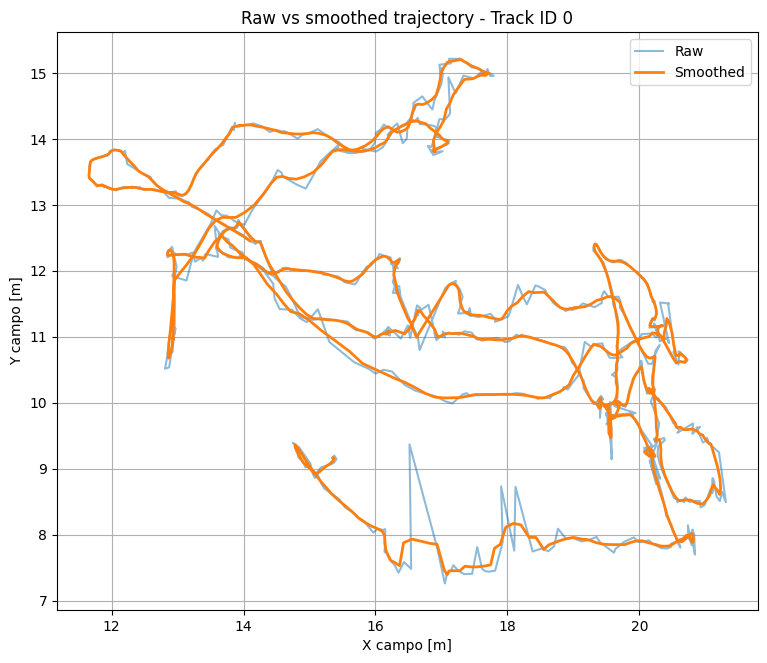

In [13]:
fig, ax = plt.subplots(
    figsize=(14, 7.5)
)

ax.plot(
    player["court_x"],
    player["court_y"],
    alpha=0.5,
    label="Raw",
)

ax.plot(
    player["court_x_smooth"],
    player["court_y_smooth"],
    linewidth=2,
    label="Smoothed",
)

ax.set_xlabel("X campo [m]")
ax.set_ylabel("Y campo [m]")

ax.set_title(
    f"Raw vs smoothed trajectory - Track ID {TRACK_ID}"
)

ax.set_aspect("equal")

ax.grid(True)
ax.legend()

plt.show()

Calcolo spostamenti
Delta temporali e spaziali

In [14]:
group_cols = [
    "track_id",
    "segment_id",
]

traj_df["dt"] = (
    traj_df
    .groupby(group_cols)["time"]
    .diff()
)

traj_df["dx"] = (
    traj_df
    .groupby(group_cols)["court_x_smooth"]
    .diff()
)

traj_df["dy"] = (
    traj_df
    .groupby(group_cols)["court_y_smooth"]
    .diff()
)

Distanza tra frame consecutivi
Formula:
\[
d = \sqrt{(\Delta x)^2 + (\Delta y)^2}
\]

In [15]:
traj_df["step_distance_m"] = np.sqrt(
    traj_df["dx"] ** 2
    + traj_df["dy"] ** 2
)

traj_df[
    [
        "frame",
        "track_id",
        "dx",
        "dy",
        "step_distance_m",
    ]
].head(20)

,frame,track_id,dx,dy,step_distance_m
0,2,0,NaN,NaN,NaN
1,3,0,0.005283,0.009163,0.010577
2,4,0,0.010204,-0.004826,0.011288
3,5,0,0.003517,-0.013218,0.013678
4,6,0,-0.005910,-0.018561,0.019479
5,7,0,-0.020948,-0.025602,0.033080
6,8,0,-0.039809,-0.035598,0.053404
7,9,0,-0.058180,-0.039267,0.070191
8,10,0,-0.052414,-0.042981,0.067784
9,11,0,-0.048617,-0.040922,0.063547


Velocità instantanea

\[
v = \frac{d}{\Delta t}
\]

In [16]:
traj_df["speed_m_s"] = (
    traj_df["step_distance_m"]
    / traj_df["dt"]
)

traj_df.loc[
    traj_df["dt"] <= 0,
    "speed_m_s"
] = np.nan

## Sanity check velocità
Per ora non cancelliamo automaticamente gli outlier: li individuiamo.

In [17]:
traj_df["speed_m_s"].describe()

,speed_m_s
count,10578.000000
mean,2.054324
std,1.536745
min,0.000000
25%,0.915058
50%,1.683417
75%,2.808011
max,18.383894


Ricerca velocità anomale

In [18]:
SPEED_WARNING_THRESHOLD = 12.0



speed_outliers = traj_df[
    traj_df["speed_m_s"]
    > SPEED_WARNING_THRESHOLD
]

print(
    "Osservazioni con velocità >",
    SPEED_WARNING_THRESHOLD,
    "m/s:",
    len(speed_outliers),
)

speed_outliers[
    [
        "frame",
        "track_id",
        "court_x_smooth",
        "court_y_smooth",
        "speed_m_s",
    ]
].head(20)

Osservazioni con velocità > 12.0 m/s: 7


,frame,track_id,court_x_smooth,court_y_smooth,speed_m_s
3123,6,6,16.865096,12.597395,14.664794
4840,795,8,13.708494,6.261082,12.605937
4953,113,9,24.544567,7.633409,12.061692
4954,114,9,24.468817,7.073689,14.120559
4955,115,9,24.374127,6.383197,17.423873
4956,116,9,24.257361,5.657171,18.383894
4957,117,9,24.108510,4.949854,18.070242


In [19]:
print(
    "Velocità massima:",
    traj_df["speed_m_s"].max(),
    "m/s"
)

print(
    "Velocità media:",
    traj_df["speed_m_s"].mean(),
    "m/s"
)

print(
    "Percentuale osservazioni > 12 m/s:",
    f"{100 * len(speed_outliers) / len(traj_df):.2f}%"
)

Velocità massima: 18.38389396742368 m/s
Velocità media: 2.0543236247995167 m/s
Percentuale osservazioni > 12 m/s: 0.07%


## Calcolo accelerazione
\[
a = \frac{\Delta v}{\Delta t}
\]

In [20]:
traj_df["dv"] = (
    traj_df
    .groupby(group_cols)["speed_m_s"]
    .diff()
)

traj_df["acceleration_m_s2"] = (
    traj_df["dv"]
    / traj_df["dt"]
)

traj_df.loc[
    traj_df["dt"] <= 0,
    "acceleration_m_s2"
] = np.nan

## Direzione
angolo di movimento

In [21]:
traj_df["direction_rad"] = np.arctan2(
    traj_df["dy"],
    traj_df["dx"],
)

traj_df["direction_deg"] = np.degrees(
    traj_df["direction_rad"]
)

Distanza percorsa

In [22]:
traj_df["cumulative_distance_m"] = (
    traj_df["step_distance_m"]
    .fillna(0)
    .groupby(traj_df["track_id"])
    .cumsum()
)

## Statistiche individuali
Player trajectory summary

In [23]:
traj_df["valid_dt"] = traj_df["dt"].where(
    traj_df["dt"] > 0,
    0
)

In [24]:
trajectory_summary = (
    traj_df
    .groupby("track_id")
    .agg(
        observations=("frame", "count"),

        segments=(
            "segment_id",
            "nunique",
        ),

        first_time=(
            "time",
            "min",
        ),

        last_time=(
            "time",
            "max",
        ),

        observed_duration_s=(
            "valid_dt",
            "sum",
        ),

        total_distance_m=(
            "step_distance_m",
            "sum",
        ),

        mean_speed_m_s=(
            "speed_m_s",
            "mean",
        ),

        max_speed_m_s=(
            "speed_m_s",
            "max",
        ),

        mean_acceleration_m_s2=(
            "acceleration_m_s2",
            "mean",
        ),
    )
)

trajectory_summary["time_span_s"] = (
    trajectory_summary["last_time"]
    - trajectory_summary["first_time"]
)

trajectory_summary = (
    trajectory_summary
    .sort_values(
        "total_distance_m",
        ascending=False,
    )
)

trajectory_summary.head(20)

trajectory_summary["duration_s"] = (
    trajectory_summary["last_time"]
    - trajectory_summary["first_time"]
)

trajectory_summary = (
    trajectory_summary
    .sort_values(
        "total_distance_m",
        ascending=False,
    )
)

trajectory_summary.head(20)

,observations,segments,first_time,last_time,observed_duration_s,total_distance_m,mean_speed_m_s,max_speed_m_s,mean_acceleration_m_s2,time_span_s,duration_s
track_id,,,,,,,,,,,
14,971,12,5.32,46.44,38.76,85.329688,2.213652,8.904551,0.054322,41.12,41.12
4,1106,3,0.04,46.44,44.24,85.182652,1.925313,8.260456,0.011149,46.40,46.40
11,1035,5,4.44,46.44,41.44,80.694479,1.952125,8.742986,0.155526,42.00,42.00
0,1127,3,0.04,46.44,45.16,74.735192,1.655075,10.227598,0.173792,46.40,46.40
15,851,4,10.60,46.44,34.04,69.899293,2.059023,6.515440,0.087451,35.84,35.84
6,896,3,0.08,36.32,35.84,66.196972,1.849224,14.664794,-0.139759,36.24,36.24
8,807,2,0.64,33.04,32.28,56.465710,1.752610,12.605937,0.065659,32.40,32.40
20,495,1,26.64,46.44,19.80,55.670774,2.813230,7.192020,-0.043223,19.80,19.80
1,675,6,0.04,32.68,26.76,49.591402,1.853191,9.864915,0.318546,32.64,32.64


## Visualizzazione traiettoria sul campo
Dimensioni baseline campo

In [25]:
COURT_LENGTH = 28.6512
COURT_WIDTH = 15.24

Traietoria per un giocatore

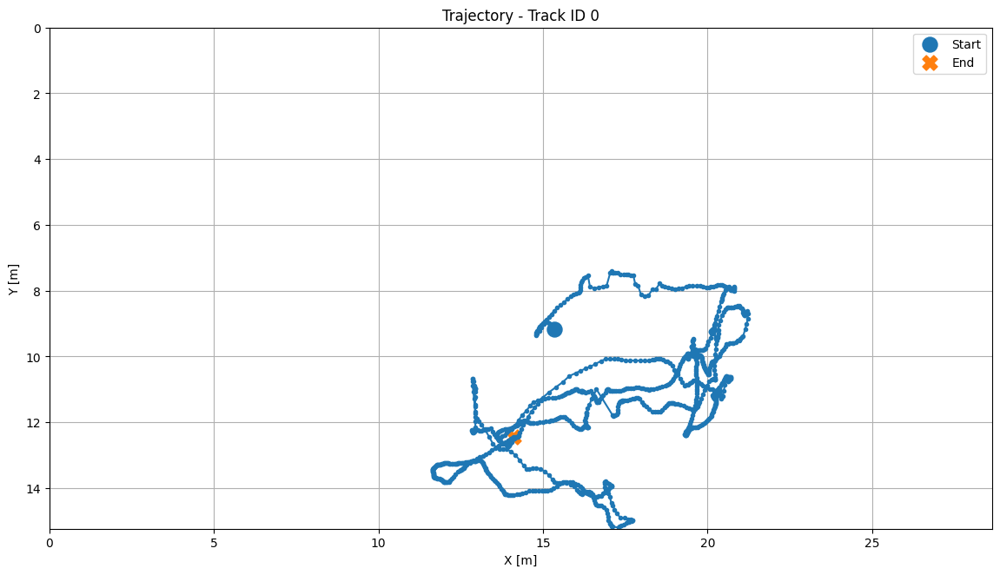

In [26]:
player = traj_df[
    traj_df["track_id"] == TRACK_ID
].copy()

fig, ax = plt.subplots(
    figsize=(14, 7.5)
)

ax.set_xlim(
    0,
    COURT_LENGTH,
)

ax.set_ylim(
    COURT_WIDTH,
    0,
)

ax.set_aspect("equal")

ax.plot(
    player["court_x_smooth"],
    player["court_y_smooth"],
    marker=".",
)

ax.scatter(
    player.iloc[0]["court_x_smooth"],
    player.iloc[0]["court_y_smooth"],
    s=150,
    label="Start",
)

ax.scatter(
    player.iloc[-1]["court_x_smooth"],
    player.iloc[-1]["court_y_smooth"],
    s=150,
    marker="X",
    label="End",
)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")

ax.set_title(
    f"Trajectory - Track ID {TRACK_ID}"
)

ax.grid(True)
ax.legend()

plt.show()

Velocità nel tempo

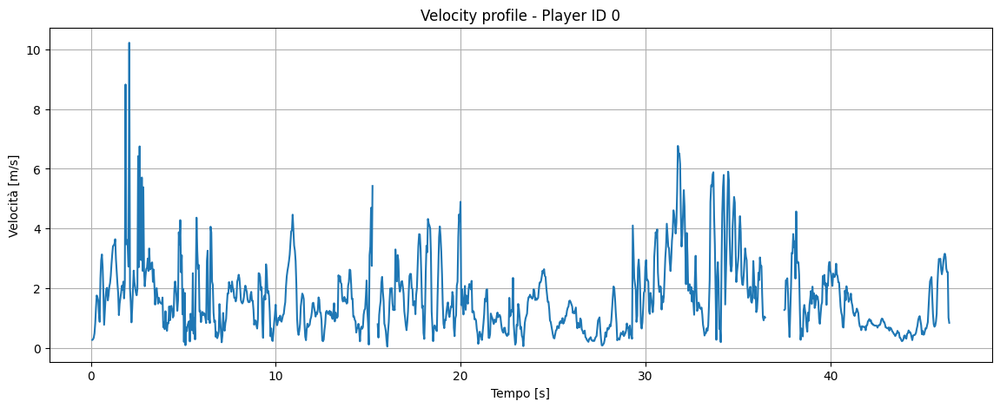

In [27]:
plt.figure(figsize=(14, 5))

plt.plot(
    player["time"],
    player["speed_m_s"],
)

plt.xlabel("Tempo [s]")
plt.ylabel("Velocità [m/s]")

plt.title(
    f"Velocity profile - Player ID {TRACK_ID}"
)

plt.grid(True)

plt.show()

Visualizzazione multi player

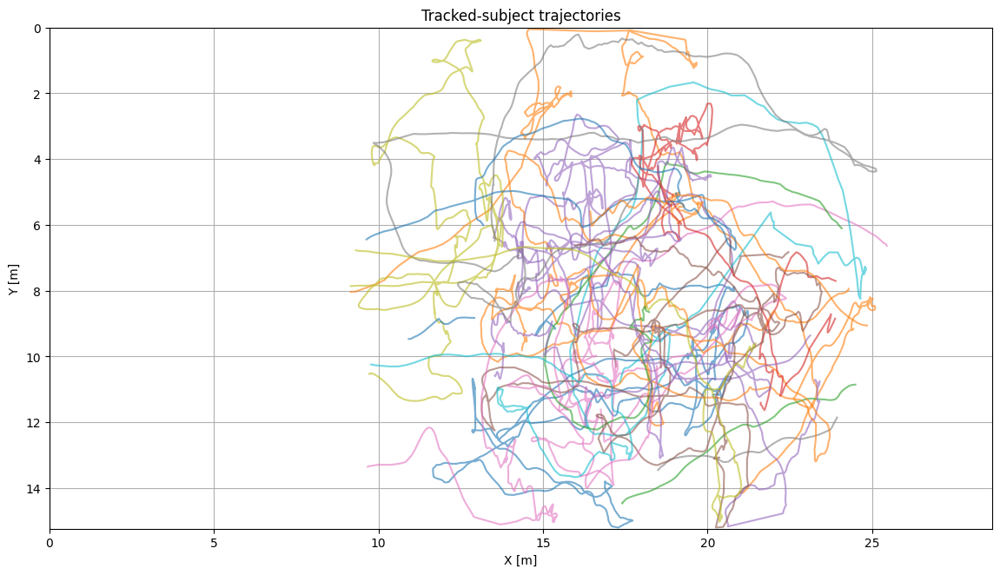

In [28]:
fig, ax = plt.subplots(
    figsize=(14, 7.5)
)

ax.set_xlim(
    0,
    COURT_LENGTH,
)

ax.set_ylim(
    COURT_WIDTH,
    0,
)

ax.set_aspect("equal")

for track_id, player_track in traj_df.groupby(
    "track_id"
):

    ax.plot(
        player_track["court_x_smooth"],
        player_track["court_y_smooth"],
        alpha=0.6,
        label=f"ID {track_id}",
    )

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")

ax.set_title(
    "Tracked-subject trajectories"
)

ax.grid(True)

plt.show()

Output Tabellare

In [29]:
trajectory_columns = [
    "frame",
    "time",
    "track_id",

    "court_x",
    "court_y",

    "court_x_smooth",
    "court_y_smooth",

    "segment_id",

    "step_distance_m",
    "cumulative_distance_m",

    "speed_m_s",
    "acceleration_m_s2",

    "direction_deg",
]

trajectory_output = traj_df[
    trajectory_columns
].copy()

trajectory_output.head()

,frame,time,track_id,court_x,court_y,court_x_smooth,court_y_smooth,segment_id,step_distance_m,cumulative_distance_m,speed_m_s,acceleration_m_s2,direction_deg
0,2,0.04,0,15.356175,9.159191,15.352471,9.161524,1,NaN,0.000000,NaN,NaN,NaN
1,3,0.08,0,15.352741,9.158291,15.357754,9.170687,1,0.010577,0.010577,0.264422,NaN,60.034061
2,4,0.12,0,15.348497,9.167090,15.367958,9.165861,1,0.011288,0.021865,0.282197,0.444366,-25.309188
3,5,0.16,0,15.373603,9.198176,15.371475,9.152643,1,0.013678,0.035543,0.341950,1.493817,-75.101988
4,6,0.20,0,15.408776,9.146559,15.365565,9.134082,1,0.019479,0.055022,0.486976,3.625671,-107.662712


## Verifica ID 9

In [30]:
window_all_tracks = traj_df[
    traj_df["frame"].between(112, 118)
].copy()

display(
    window_all_tracks[
        [
            "frame",
            "track_id",
            "court_x",
            "court_y",
            "court_x_smooth",
            "court_y_smooth",
            "speed_m_s",
        ]
    ]
    .sort_values(
        ["frame", "track_id"]
    )
)

,frame,track_id,court_x,court_y,court_x_smooth,court_y_smooth,speed_m_s
110,112,0,20.623940,7.803598,20.604254,7.900105,1.013193
1237,112,1,24.997152,8.251233,25.014139,8.239676,0.487734
2061,112,4,17.446787,9.022380,17.463498,9.013993,2.394977
3226,112,6,21.983790,7.796033,21.982888,7.828176,1.514304
4161,112,8,12.039747,9.232204,12.039403,9.242953,0.542261
4952,112,9,24.574774,8.145548,24.591785,8.113561,2.364558
5131,112,11,24.284601,7.776676,24.290424,7.944894,NaN
111,113,0,20.575417,7.889809,20.571423,7.927532,1.069498
1238,113,1,25.017925,8.185788,24.986446,8.247107,0.716801
2062,113,4,17.362791,8.989909,17.372279,8.979386,2.439069


In [35]:
frame_speed_summary = (
    traj_df[
        traj_df["frame"].between(105, 125)
    ]
    .groupby("frame")
    .agg(
        mean_speed=("speed_m_s", "mean"),
        max_speed=("speed_m_s", "max"),
        tracks=("track_id", "nunique"),
    )
)

display(frame_speed_summary)

,mean_speed,max_speed,tracks
frame,,,
105,1.541966,4.672673,7
106,1.870580,5.565936,6
107,1.989654,4.821680,6
108,1.856404,4.472386,6
109,1.876523,2.785701,6
110,1.268948,2.398834,6
111,1.380011,2.377748,6
112,1.386171,2.394977,7
113,2.787637,12.061692,7


In [31]:
OUTLIER_TRACK_ID = 9

outlier_track = traj_df[
    traj_df["track_id"] == OUTLIER_TRACK_ID
].copy()

outlier_window = outlier_track[
    outlier_track["frame"].between(105, 125)
]

display(
    outlier_window[
        [
            "frame",
            "court_x",
            "court_y",
            "court_x_smooth",
            "court_y_smooth",
            "speed_m_s",
            "segment_id",
        ]
    ]
)

,frame,court_x,court_y,court_x_smooth,court_y_smooth,speed_m_s,segment_id
4945,105,24.734232,7.389863,24.694910,7.542060,4.672673,4
4946,106,24.669197,7.547597,24.666323,7.762855,5.565936,4
4947,107,24.521595,8.164639,24.658155,7.955549,4.821680,4
4948,108,24.665980,8.336037,24.652957,8.134369,4.472386,4
4949,109,24.699772,8.339607,24.643854,8.245424,2.785701,4
4950,110,24.708242,8.283963,24.654490,8.241606,0.282510,4
4951,111,24.623682,8.102875,24.620333,8.203732,1.275034,4
4952,112,24.574774,8.145548,24.591785,8.113561,2.364558,4
4953,113,24.495195,8.146667,24.544567,7.633409,12.061692,4
4954,114,24.557032,7.888751,24.468817,7.073689,14.120559,4


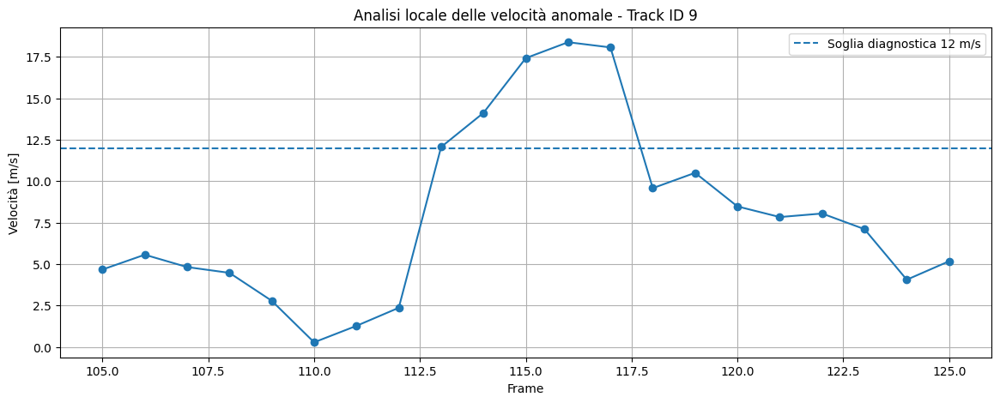

In [32]:
plt.figure(figsize=(14, 5))

plt.plot(
    outlier_window["frame"],
    outlier_window["speed_m_s"],
    marker="o",
)

plt.axhline(
    12.0,
    linestyle="--",
    label="Soglia diagnostica 12 m/s",
)

plt.xlabel("Frame")
plt.ylabel("Velocità [m/s]")

plt.title(
    "Analisi locale delle velocità anomale - Track ID 9"
)

plt.grid()
plt.legend()

plt.show()

## Diagnostica visiva delle track anomale

Vengono visualizzate le bounding box associate alle track ID 9 e 12 nei frame 112–118, per verificare se l'anomalia di velocità sia dovuta a un salto della bounding box, a un cambio di soggetto oppure alla creazione di una nuova track.

In [48]:
SPORTSMOT_ROOT = DRIVE_ROOT / "datasets" / "sportsmot"

SEQUENCE_DIR = (
    SPORTSMOT_ROOT
    / "val"
    / SEQUENCE_NAME
)

FRAMES_DIR = SEQUENCE_DIR / "img1"

print(FRAMES_DIR)
print("Exists:", FRAMES_DIR.exists())

/content/drive/MyDrive/basketball-thesis/datasets/sportsmot/val/v_00HRwkvvjtQ_c001/img1
Exists: True


In [49]:
from pathlib import Path
import pandas as pd

DRIVE_ROOT = Path("/content/drive/MyDrive/basketball-thesis")
SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

TRACKS_FILE = (
    DRIVE_ROOT
    / "experiments"
    / "bytetrack_baseline"
    / f"{SEQUENCE_NAME}_tracks.csv"
)

tracks_df = pd.read_csv(TRACKS_FILE)

print("Tracking rows:", len(tracks_df))
print(tracks_df.columns.tolist())

Tracking rows: 10911
['frame', 'time', 'track_id', 'confidence', 'x1', 'y1', 'x2', 'y2']


In [51]:
TRACK_IDS_DEBUG = [9, 12]
FRAME_START = 112
FRAME_END = 118

debug_tracks = tracks_df[
    tracks_df["track_id"].isin(TRACK_IDS_DEBUG)
    & tracks_df["frame"].between(FRAME_START, FRAME_END)
].copy()

# bottom-center della bounding box
debug_tracks["pixel_x"] = (
    debug_tracks["x1"] + debug_tracks["x2"]
) / 2

debug_tracks["pixel_y"] = debug_tracks["y2"]

display(
    debug_tracks[
        [
            "frame",
            "track_id",
            "confidence",
            "x1",
            "y1",
            "x2",
            "y2",
            "pixel_x",
            "pixel_y",
        ]
    ].sort_values(["frame", "track_id"])
)

,frame,track_id,confidence,x1,y1,x2,y2,pixel_x,pixel_y
898,112,9,0.712164,1174.463257,229.191025,1239.118164,384.829712,1206.790710,384.829712
905,113,9,0.712112,1168.845947,241.172089,1232.241333,385.043640,1200.543640,385.043640
912,114,9,0.634166,1170.599976,199.200790,1230.478516,377.021210,1200.539246,377.021210
919,115,9,0.778325,1128.636963,168.708847,1187.669800,318.943054,1158.153381,318.943054
926,116,9,0.774656,1092.357910,161.891327,1170.928833,303.577301,1131.643372,303.577301
933,117,9,0.734224,1070.641724,159.534073,1152.138794,287.560669,1111.390259,287.560669
940,118,9,0.813152,1047.697632,162.009583,1142.074097,283.351807,1094.885864,283.351807
942,118,12,0.751789,1115.973389,198.491196,1181.531738,330.103668,1148.752563,330.103668


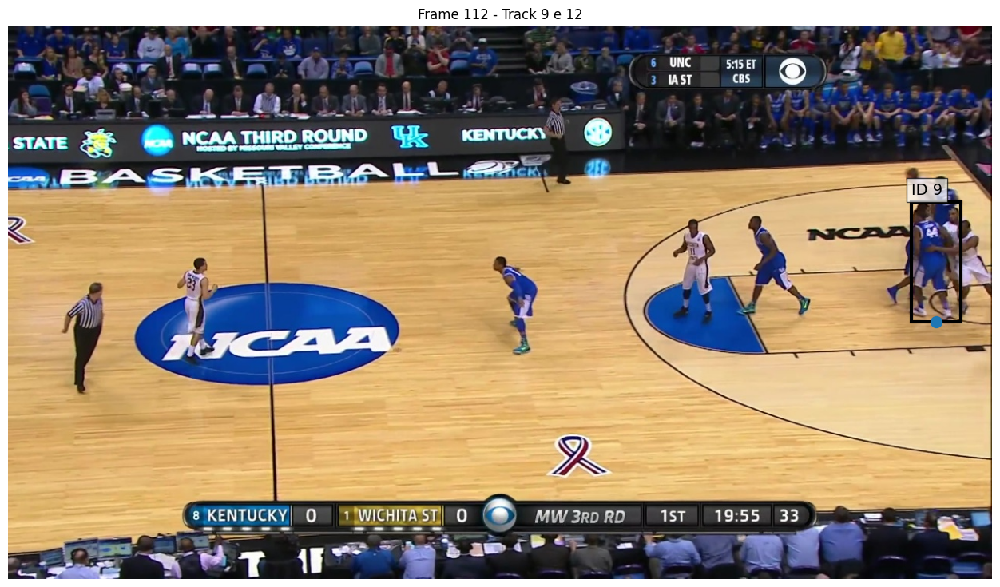

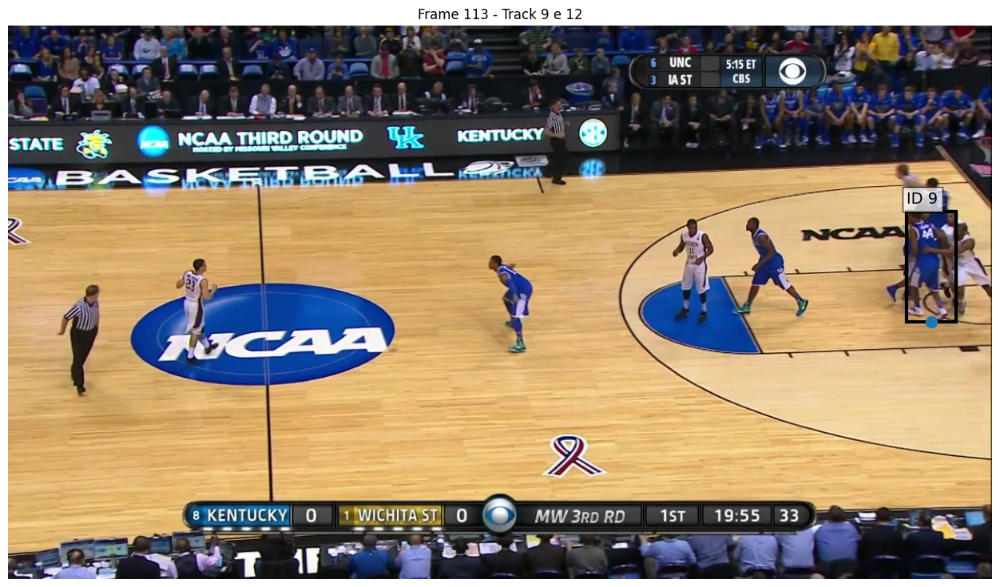

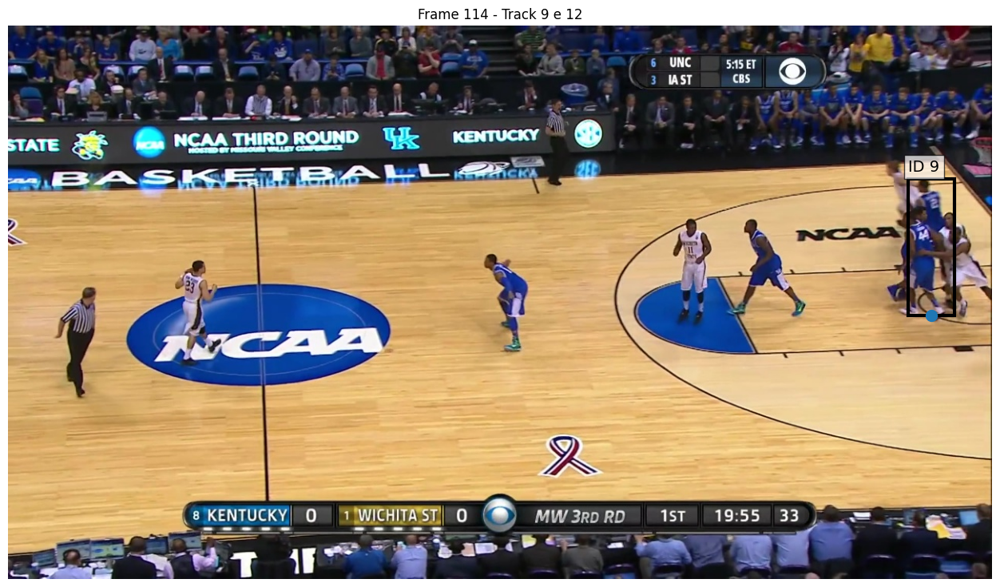

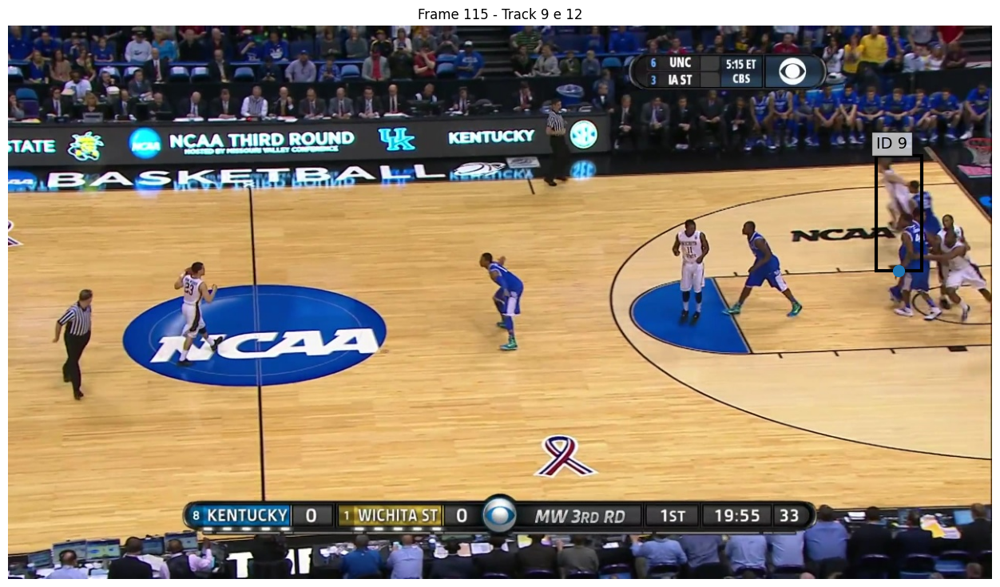

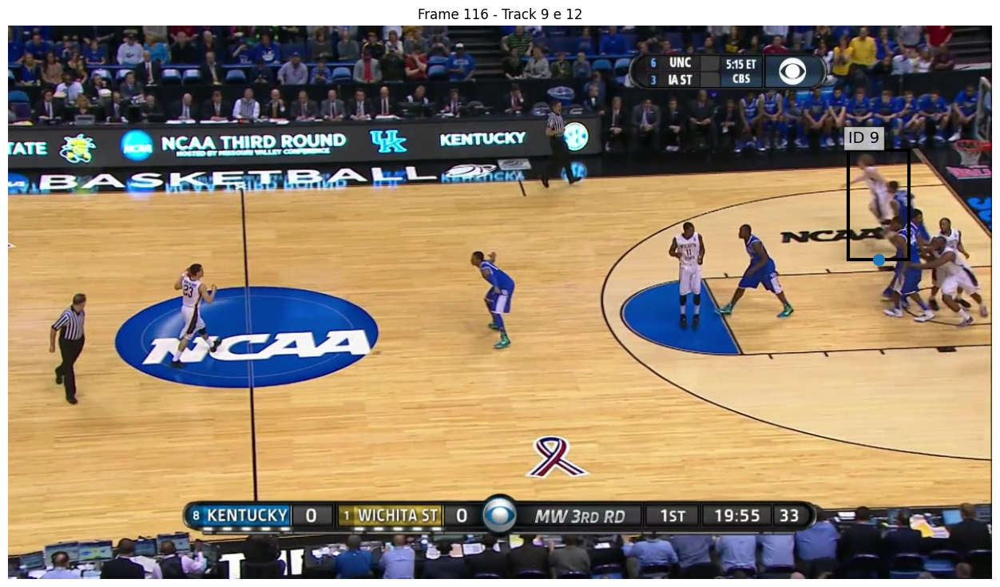

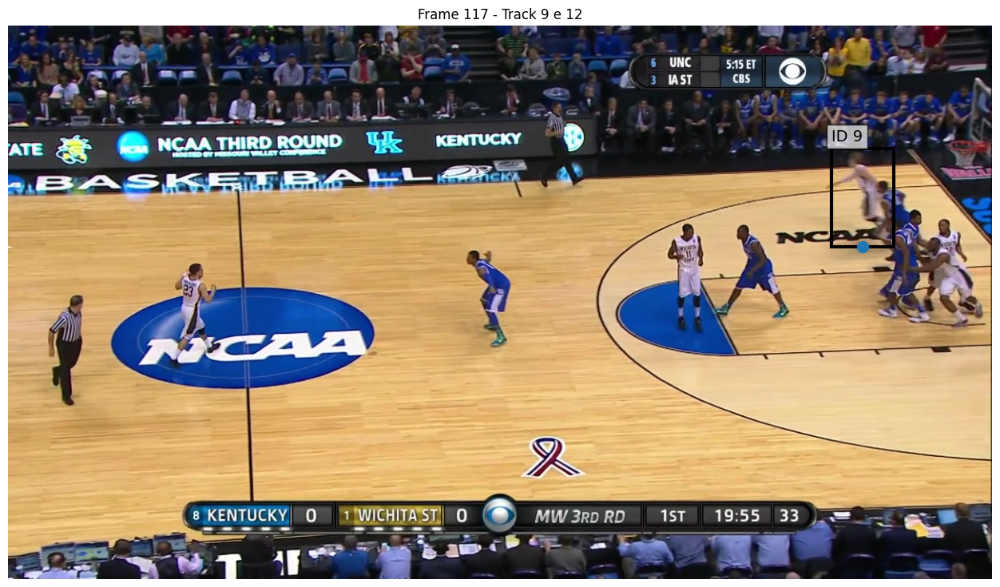

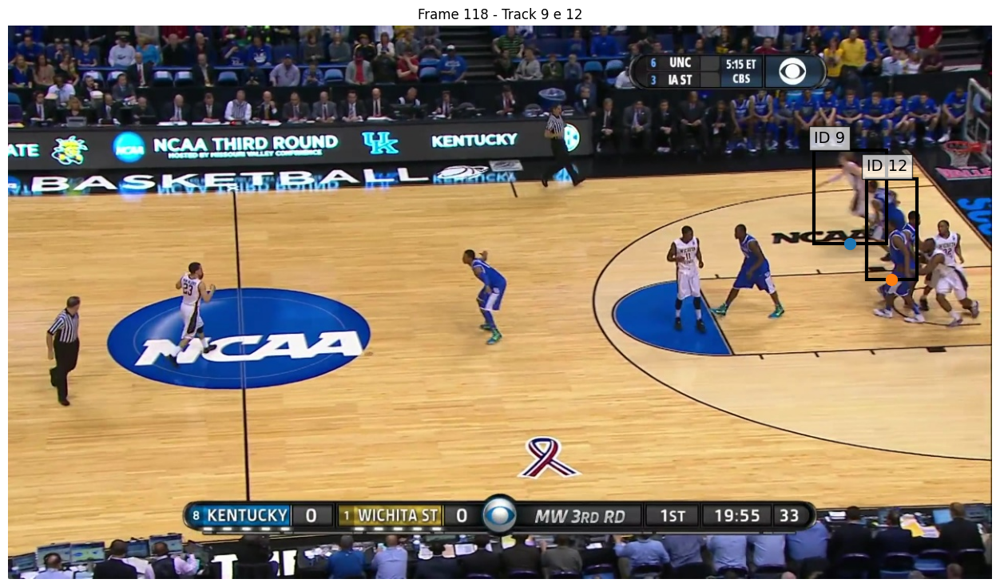

In [52]:
import matplotlib.pyplot as plt
import cv2

for frame_number in range(FRAME_START, FRAME_END + 1):

    frame_path = (
        FRAMES_DIR
        / f"{frame_number:06d}.jpg"
    )

    frame_bgr = cv2.imread(
        str(frame_path)
    )

    assert frame_bgr is not None, (
        f"Frame non trovato: {frame_path}"
    )

    frame_rgb = cv2.cvtColor(
        frame_bgr,
        cv2.COLOR_BGR2RGB
    )

    frame_debug = debug_tracks[
        debug_tracks["frame"] == frame_number
    ]

    plt.figure(figsize=(16, 9))

    plt.imshow(frame_rgb)

    for _, row in frame_debug.iterrows():

        x1 = row["x1"]
        y1 = row["y1"]
        x2 = row["x2"]
        y2 = row["y2"]

        track_id = int(
            row["track_id"]
        )

        width = x2 - x1
        height = y2 - y1

        rect = plt.Rectangle(
            (x1, y1),
            width,
            height,
            fill=False,
            linewidth=3
        )

        plt.gca().add_patch(rect)

        plt.text(
            x1,
            y1 - 10,
            f"ID {track_id}",
            fontsize=14,
            bbox=dict(
                facecolor="white",
                alpha=0.7
            )
        )

        # bottom-center
        px = (x1 + x2) / 2
        py = y2

        plt.scatter(
            px,
            py,
            s=100
        )

    plt.title(
        f"Frame {frame_number} - Track 9 e 12"
    )

    plt.axis("off")
    plt.show()

Salvataggio Dataset Completo

In [33]:
OUTPUT_CSV = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_player_trajectories.csv"
)

trajectory_output.to_csv(
    OUTPUT_CSV,
    index=False,
)

print("Salvato:", OUTPUT_CSV)

Salvato: /content/drive/MyDrive/basketball-thesis/experiments/player_trajectories/v_00HRwkvvjtQ_c001/v_00HRwkvvjtQ_c001_player_trajectories.csv


Salvataggio Summary

In [34]:
SUMMARY_CSV = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_trajectory_summary.csv"
)

trajectory_summary.to_csv(
    SUMMARY_CSV
)

print("Salvato:", SUMMARY_CSV)

Salvato: /content/drive/MyDrive/basketball-thesis/experiments/player_trajectories/v_00HRwkvvjtQ_c001/v_00HRwkvvjtQ_c001_trajectory_summary.csv


### Caso di ID switch

Durante l’analisi delle velocità è stato individuato un valore cinematicamente non plausibile, superiore a 17 m/s.

L’ispezione visiva dei frame corrispondenti ha mostrato che il medesimo `track_id` viene associato, in un breve intervallo temporale, a due giocatori differenti.

L’anomalia non è quindi dovuta a un reale movimento del soggetto, ma a un errore di associazione del tracker.

Questo ID switch provoca una discontinuità nella bounding box e, di conseguenza, nella posizione bottom-center utilizzata per la proiezione sul campo. L’errore si propaga quindi alle coordinate metriche e alle grandezze cinematiche derivate, producendo velocità non realistiche.

## Interpretazione metodologica

La ricostruzione delle traiettorie rappresenta il passaggio dalle semplici coordinate spaziali ad una rappresentazione spazio-temporale del comportamento dei giocatori.

Il notebook precedente fornisce infatti una successione di posizioni indipendenti:

(frame, track_id, x, y)

mentre questa fase collega le osservazioni appartenenti allo stesso `track_id` nel tempo.

Per ogni giocatore viene quindi costruita una sequenza:

(x₁, y₁, t₁),
(x₂, y₂, t₂),
...,
(xₙ, yₙ, tₙ).

Da tale rappresentazione vengono derivate informazioni cinematiche quali distanza percorsa, velocità, accelerazione e direzione di movimento.

Prima del calcolo delle feature viene inoltre applicato un semplice smoothing temporale alle coordinate.

Questa operazione è necessaria perché piccoli errori di localizzazione possono produrre variazioni artificiali molto elevate quando vengono calcolate le derivate temporali.

Le coordinate originali vengono comunque conservate, permettendo un confronto tra traiettoria raw e traiettoria smussata.

## Limiti della baseline

La qualità delle traiettorie dipende direttamente dai moduli precedenti della pipeline.

In particolare, gli errori possono propagarsi secondo la catena:

detection
→ tracking
→ bottom-center
→ omografia
→ coordinate sul campo
→ traiettoria
→ velocità e accelerazione.

Un errore relativamente piccolo nelle coordinate spaziali può quindi essere amplificato nel calcolo della velocità e, soprattutto, dell'accelerazione.

Ulteriori fonti di errore includono:

- ID switch del tracker;
- frammentazione delle tracce;
- frame mancanti;
- bounding box imprecise;
- omografia non aggiornata durante movimenti della telecamera;
- smoothing non ottimale.

Per questo motivo i risultati cinematici ottenuti in questa fase devono essere interpretati insieme alla qualità dei moduli precedenti.